<a href="https://colab.research.google.com/github/victoria-riley-barnett/intermediate-ml/blob/main/01_tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 lab: tensors, shapes, and encoding a category

Get a working environment, then get reps on the three things that break most often: shapes, broadcasting, and turning non-numbers into numbers.

**Predict** cells come before the code that answers them. Write your guess in the cell, then run it. Being wrong is the useful part, as long as you committed to an answer first.

**To submit:** run the notebook top to bottom with outputs, answer every Predict, Investigate, Modify, and Make cell, and upload the `.ipynb`.

---

## 1. Set up

**Colab** runs on Google's machines. Libraries preinstalled, free GPU, nothing to set up. The session resets when it idles and files live in Drive.

**Local** runs on your laptop. Files stay put, it works offline, you install things yourself.

For local, from a terminal in your coursework folder:

```
python3 -m venv .venv
source .venv/bin/activate          # Windows: .venv\Scripts\activate
pip install torch pandas numpy seaborn matplotlib jupyterlab
jupyter lab
```

`python3 -m venv .venv` makes a folder holding the libraries for this project only, so two projects can want two different versions of the same library without breaking each other. You know it worked when your prompt gets a `(.venv)` in front of it.

In [ ]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q torch seaborn

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt

print("pandas", pd.__version__)
print("numpy ", np.__version__)
print("torch ", torch.__version__)

pandas 3.0.3
numpy  2.5.1
torch  2.13.0


Three lines printed means you are set up. If not, the cause is almost always one of two things.

**The kernel is not your venv.** Jupyter runs your code in a *kernel*, which is a separate Python process, and it is not necessarily the one you just installed into. If `import torch` fails right after you installed torch, this is why. Run this and look at the path:

In [ ]:
import sys
sys.executable

'/Users/v/projects/teaching/411/.venv/bin/python'

If that path does not contain `.venv`, switch kernels: in JupyterLab the picker is the button at the top right, or use **Kernel > Change Kernel**. On Colab there is nothing to change.

**The venv is not activated.** If `pip` says "command not found," or things install but never import, check your terminal prompt for `(.venv)` at the front. No `(.venv)`, no activation, and `pip` is putting packages somewhere else entirely.

### The stack

| Library | Holds | Reach for it when |
|---|---|---|
| pandas | tables with labels, mixed types, gaps | loading and cleaning |
| NumPy | a plain typed grid | doing math on clean numbers |
| PyTorch | a typed grid that runs on a GPU and can differentiate | building models |
| seaborn / matplotlib | plots | looking at any of it |

Docs, which you should expect to open constantly:
[pandas](https://pandas.pydata.org/docs/user_guide/10min.html) ·
[NumPy](https://numpy.org/doc/stable/user/absolute_beginners.html) ·
[PyTorch tensors](https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html) ·
[seaborn](https://seaborn.pydata.org/tutorial/introduction.html)

---

## 2. The data

344 penguins, seven columns, from the Palmer Archipelago.

In [ ]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
penguins.shape, penguins.isna().sum().sum()

((344, 7), np.int64(19))

`.shape` gives `(rows, columns)`. `.isna()` marks every missing cell `True`, and the two `.sum()` calls add those up per column and then overall.

You get at the parts of a DataFrame by name. These three are the ones you will use constantly:

In [ ]:
penguins.columns                  # every column name
penguins['species']               # one column, as a Series
penguins[['species', 'island']]   # two columns, as a smaller DataFrame

,species,island
0,Adelie,Torgersen
1,Adelie,Torgersen
2,Adelie,Torgersen
3,Adelie,Torgersen
4,Adelie,Torgersen
...,...,...
339,Gentoo,Biscoe
340,Gentoo,Biscoe
341,Gentoo,Biscoe
342,Gentoo,Biscoe


One set of brackets with a string gives a single column. Two sets with a list inside gives a table. Mixing these up is the most common pandas mistake there is, and the giveaway is a `KeyError` naming a column you can plainly see exists.

**Predict.** `dropna()` drops every row with any missing value. Nineteen cells are missing. How many of the 344 rows survive?

In [ ]:
my_guess = 0      # replace with your number

df = penguins.dropna().reset_index(drop=True)
my_guess, df.shape

(0, (333, 7))

Fewer rows go than cells are missing, because some rows are missing more than one field.

Dropping rows is a decision with consequences, not housekeeping. Every number below describes the survivors. It is defensible here because the gaps are few and scattered; it would not be if rows went missing for a reason connected to what you are predicting.

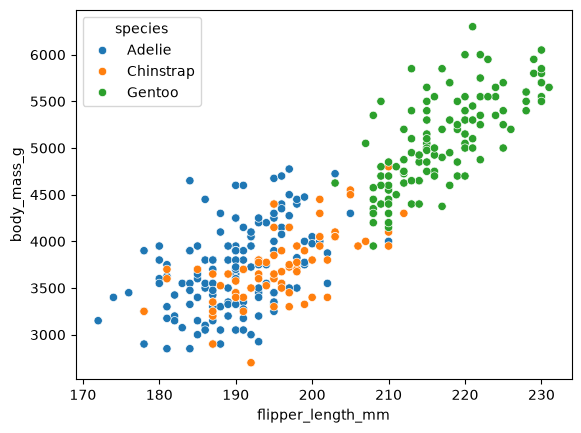

In [ ]:
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species');

**Investigate.** Redraw that plot with a different pair of columns by changing the column names in the `x` and `y` parameters of the `sns.scatterplot()` function. Which pair separates the species most cleanly? Which pair barely separates them at all?

column options: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`

In [ ]:
# your code here


---

## 3. Columns into tensors

In [ ]:
flipper = df['flipper_length_mm']

flipper.head(3).tolist(), flipper.to_numpy()[:3]

([181.0, 186.0, 195.0], array([181., 186., 195.]))

In [ ]:
flipper_t = torch.tensor(flipper.to_numpy(), dtype=torch.float32)
flipper_t.shape, flipper_t.dtype, flipper_t.ndim

(torch.Size([333]), torch.float32, 1)

`.shape`, `.dtype`, `.ndim`. Check these three first whenever anything breaks.

Each conversion step drops something. `.to_numpy()` turns a pandas Series into a NumPy array and drops the index and the column name. `torch.tensor(...)` turns that array into a tensor.

The `dtype=torch.float32` is not bookkeeping you can skip. Leave it out and PyTorch guesses from the input, so a column of whole numbers becomes `int64` and then refuses to multiply with float weights several cells later. Passing it every time is the cheap habit.

**Predict.** What `dtype` does each one get?

In [ ]:
# torch.tensor([1, 2, 3])  ->
# torch.tensor([1.0, 2.0]) ->

torch.tensor([1, 2, 3]).dtype, torch.tensor([1.0, 2.0]).dtype

(torch.int64, torch.float32)

Integer and float tensors are different types, and PyTorch refuses to mix them in places you would expect it to cope. Common first bug.

**Predict.** Four columns instead of one. What shape?

In [ ]:
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# your guess:
X = torch.tensor(df[features].to_numpy(), dtype=torch.float32)
X.shape

torch.Size([333, 4])

Rows are examples, columns are features. When documentation says it expects `(n_samples, n_features)`, this is the shape it means.

---

## 4. Weighted sums

A prediction is each feature times a weight, all added up. Invent four weights and try one penguin.

In [ ]:
w = torch.tensor([2.0, -1.5, 0.5, 0.01])

X[0], X[0] @ w

(tensor([  39.1000,   18.7000,  181.0000, 3750.0000]), tensor(178.1500))

`@` is the dot product: multiply matching slots, add them up.

Three operators look alike and do different jobs. Run this:

In [ ]:
u = torch.tensor([1.0, 2.0, 3.0])
v = torch.tensor([4.0, 5.0, 6.0])

u + v, u * v, u @ v

(tensor([5., 7., 9.]), tensor([ 4., 10., 18.]), tensor(32.))

`+` and `*` pair up matching slots and stop, so they hand back something the same shape they started with. `@` pairs them up and then adds, so it always hands back *fewer* dimensions than it started with. `torch.matmul(u, v)` is `u @ v` written out, and you will see both.

**Predict.** `X` is `(333, 4)`, `w` is `(4,)`. What shape is `X @ w`?

In [ ]:
preds = X @ w
preds.shape, preds[:5]

(torch.Size([333]), tensor([178.1500, 183.9000, 183.6000, 175.4500, 179.2000]))

333 predictions, no loop. `(333, 4) @ (4,) -> (333,)`. The inner numbers must match, and they are the ones that disappear.

These predictions mean nothing, because the weights were invented. The shape is exactly the shape of a real prediction, and learning good weights is the rest of the course.

**Predict.** A length-3 vector instead of 4. Name the error before you run it.

In [ ]:
try:
    X @ torch.randn(3)
except RuntimeError as e:
    print(e)

size mismatch, got input (333), mat (333x4), vec (3)


**Modify.** Zero out the last weight, the one on `body_mass_g`, and recompute `preds`. Then zero out the first weight instead. Why does one change the predictions far more than the other?

In [ ]:
# your code here

---

## 5. Shape drills

Most bugs this term are shape bugs. These use `torch.randn`, which fills a tensor with random numbers, so the values are irrelevant and only the shapes matter.

A shape is a tuple read left to right, one number per dimension. `(333, 4)` is 333 rows of 4. `(2, 5, 3)` is 2 blocks of 5 rows of 3.

One naming trap worth knowing now: **PyTorch calls it `dim` and NumPy calls it `axis`**, and they mean the same thing. `tensor.mean(dim=0)` and `array.mean(axis=0)` do the same job. You will find both in the same answer on StackOverflow, and neither is wrong.

In [ ]:
torch.manual_seed(0)
A = torch.randn(4, 3)
A.shape

torch.Size([4, 3])

**Predict.** Both, before running.

In [ ]:
# A.mean(dim=0).shape ->
# A.mean(dim=1).shape ->

A.mean(dim=0).shape, A.mean(dim=1).shape

(torch.Size([3]), torch.Size([4]))

**The dim you name is the axis that disappears.** `dim=0` collapses the 4 rows and leaves 3. `dim=1` collapses the 3 columns and leaves 4.

**Predict.** Same rule, three dimensions. All three.

In [ ]:
B = torch.randn(2, 5, 3)

# B.mean(dim=0).shape ->
# B.mean(dim=1).shape ->
# B.mean(dim=2).shape ->

B.mean(dim=0).shape, B.mean(dim=1).shape, B.mean(dim=2).shape

(torch.Size([5, 3]), torch.Size([2, 3]), torch.Size([2, 5]))

In [ ]:
A.mean(dim=1).shape, A.mean(dim=1, keepdim=True).shape

(torch.Size([4]), torch.Size([4, 1]))

`keepdim=True` leaves the collapsed axis in place at size 1, so the result still lines up with the original for later arithmetic.

**Predict.** Indexing versus slicing.

In [ ]:
# A[0].shape   ->
# A[0:1].shape ->

A[0].shape, A[0:1].shape

(torch.Size([3]), torch.Size([1, 3]))

Indexing removes a dimension. Slicing keeps it. Confusing the two is how you get a shape error three cells later.

### Broadcasting

Line the shapes up from the right. Each pair either matches, or one of them is 1.

In [ ]:
centered = A - A.mean(dim=0)
centered.shape, centered.mean(dim=0)

(torch.Size([4, 3]), tensor([-4.4703e-08, -1.4901e-08,  0.0000e+00]))

`(4, 3)` against `(3,)`: the 3s match, the 4 has nothing opposite it and gets stretched. Every column now averages to zero.

**Predict.** This one fails. Which two numbers does it complain about?

In [ ]:
try:
    A - A.mean(dim=1)
except RuntimeError as e:
    print(e)

The size of tensor a (3) must match the size of tensor b (4) at non-singleton dimension 1


**Modify.** Fix that line with `keepdim`, and say in a comment why it works.

In [ ]:
# your code here

---

## 6. What a matrix does

A matrix applies one rule to every row at once.

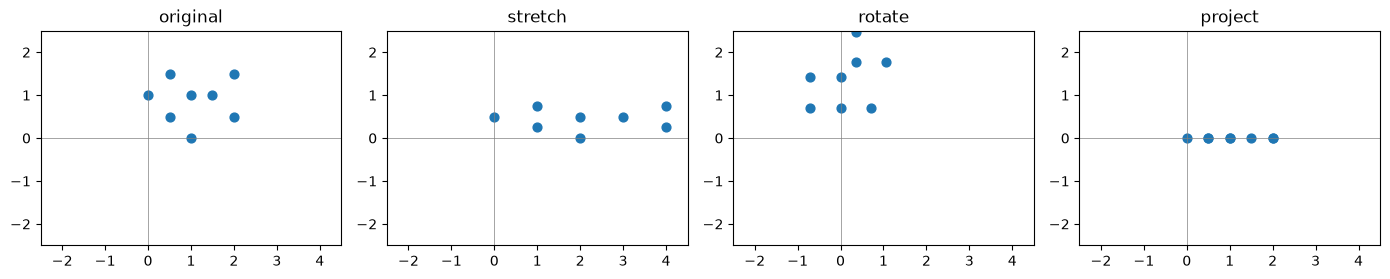

In [ ]:
pts = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0], [2.0, 0.5],
                    [0.5, 1.5], [1.5, 1.0], [2.0, 1.5], [0.5, 0.5]])

th = torch.tensor(np.pi / 4)
moves = {
    'original': torch.eye(2),
    'stretch':  torch.tensor([[2.0, 0.0], [0.0, 0.5]]),
    'rotate':   torch.tensor([[torch.cos(th), -torch.sin(th)],
                              [torch.sin(th),  torch.cos(th)]]),
    'project':  torch.tensor([[1.0, 0.0], [0.0, 0.0]]),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, (name, M) in zip(axes, moves.items()):
    moved = pts @ M.T
    ax.scatter(moved[:, 0], moved[:, 1], s=40)
    ax.set_title(name)
    ax.set_xlim(-2.5, 4.5); ax.set_ylim(-2.5, 2.5)
    ax.axhline(0, lw=0.5, color='gray'); ax.axvline(0, lw=0.5, color='gray')
    ax.set_aspect('equal')
plt.tight_layout();

`.T` transposes a tensor: it swaps rows and columns, so a `(2, 3)` becomes a `(3, 2)`.

We write `pts @ M.T` rather than `M @ pts` because our points are stored one per row. Both conventions exist and libraries disagree about which they use, so when a matrix multiply fails on shapes, transposing one side is the first thing to try.

**Predict.** These two points differ. What does `project` do to each?

In [ ]:
a = torch.tensor([3.0,  5.0])
b = torch.tensor([3.0, -2.0])

a @ moves['project'].T, b @ moves['project'].T

(tensor([3., 0.]), tensor([3., 0.]))

Two inputs, one output, and no matrix undoes it. The projection destroyed information while running. Averaging does the same: 4 and 6 average to 5, and so do 3 and 7.

**Investigate.** Apply `rotate` to `pts` twice. Then find a single matrix that does the same job in one step, and check it with `torch.allclose`.

In [ ]:
# your code here

---

## 7. Encoding a category

In [ ]:
df['species'].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

You can average flipper lengths. You cannot average Adelie and Gentoo, and a model only does arithmetic, so this column has to become numbers.

**Predict.** The obvious idea is Adelie 0, Chinstrap 1, Gentoo 2. Write down what that encoding claims about the species that is not true.

In [ ]:
# your answer here

<!-- Numbering invents an order and a spacing that are not in the data. It says Gentoo > Adelie,
and that Adelie-to-Gentoo is twice Adelie-to-Chinstrap. Nothing about the birds justifies either,
but every model built on that column acts on both. -->

The fix is one column per category, with a single 1 marking which applies. That is **one-hot encoding**.

In [ ]:
species_names = sorted(df['species'].unique())

def one_hot(labels, categories):
    out = torch.zeros(len(labels), len(categories))
    lookup = {c: i for i, c in enumerate(categories)}
    for row, label in enumerate(labels):
        out[row, lookup[label]] = 1.0
    return out

S = one_hot(df['species'], species_names)
S.shape, S[:3]

(torch.Size([333, 3]),
 tensor([[1., 0., 0.],
         [1., 0., 0.],
         [1., 0., 0.]]))

Two pieces of that function are worth naming, because you will write both a lot.

`sorted(df['species'].unique())` takes the distinct values and puts them in a fixed order. The sorting matters: without it, your column order would depend on which species happened to appear first in the file, and the encoding would change if somebody reordered the rows.

`{c: i for i, c in enumerate(categories)}` is a dict comprehension. `enumerate` hands you `(0, 'Adelie')`, `(1, 'Chinstrap')`, and so on, and the comprehension flips each pair around into a lookup from name to column number.

In [ ]:
S_pandas = torch.tensor(pd.get_dummies(df['species']).to_numpy(), dtype=torch.float32)
torch.equal(S, S_pandas)

True

`pd.get_dummies` is what you use in practice. Building it once by hand is how you know what it did.

In [ ]:
adelie    = torch.tensor([1.0, 0.0, 0.0])
chinstrap = torch.tensor([0.0, 1.0, 0.0])
gentoo    = torch.tensor([0.0, 0.0, 1.0])

per_species = torch.tensor(df.groupby('species')[features].mean().to_numpy(),
                           dtype=torch.float32)
adelie @ per_species

tensor([  38.8240,   18.3473,  190.1027, 3706.1643])

Multiplying by a one-hot vector pulls one row out of a table. Looking a value up and multiplying by a matrix are the same operation.

**Predict.** Three dot products and the distance matrix. Guess all of them.

In [ ]:
# adelie @ gentoo    ->
# adelie @ chinstrap ->
# gentoo @ chinstrap ->
# every pairwise distance ->

M = torch.stack([adelie, chinstrap, gentoo])
(adelie @ gentoo, adelie @ chinstrap, gentoo @ chinstrap), torch.cdist(M, M)

((tensor(0.), tensor(0.), tensor(0.)),
 tensor([[0.0000, 1.4142, 1.4142],
         [1.4142, 0.0000, 1.4142],
         [1.4142, 1.4142, 0.0000]]))

Every dot product is 0 and every distance is $\sqrt{2}$. The encoding says any two species have nothing in common and are all exactly equally far apart.

In [ ]:
df.groupby('species')[features].mean().round(1)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.8,18.3,190.1,3706.2
Chinstrap,48.8,18.4,195.8,3733.1
Gentoo,47.6,15.0,217.2,5092.4


**Investigate.** Using that table, is the equal-distance claim true of these birds? Name two species that are close on some measurement and give the numbers.

In [ ]:
# your answer here

No amount of training recovers what the encoding refused to write down. **How you write your data down is its representation, and choosing one is already a modeling decision.** Week 6 is where something better shows up.

---

## 8. Rank, and reading a pipeline by its shapes

Everything in this lab was one kind of object at different sizes, and every operation was a rule about shapes. Stating that directly is what lets you reason about code before you run it.

The **rank** of a tensor is how many dimensions it has. The **shape** says how big each one is.

In [ ]:
r0 = torch.tensor(3.0)          # a single number
r1 = flipper_t                  # a column
r2 = X                          # a table
r3 = torch.randn(8, 333, 4)     # a stack of tables

[(t.ndim, tuple(t.shape)) for t in (r0, r1, r2, r3)]

[(0, ()), (1, (333,)), (2, (333, 4)), (3, (8, 333, 4))]

Rank 0 is a number. Rank 1 is a column of them. Rank 2 is a table, rows by features. Rank 3 stacks tables, which is what a batch of examples looks like, and also what a colour image looks like: height by width by channel. It keeps going, and none of the rules change when it does.

Every operation you used today has one job, and that job is describable entirely in terms of shape:

| Operation | Effect on the shape |
|---|---|
| `A.mean(dim=k)` | removes axis `k` |
| `A.mean(dim=k, keepdim=True)` | sets axis `k` to 1 |
| `A[0]` | removes axis 0 |
| `A[0:1]` | keeps axis 0, at size 1 |
| broadcasting | stretches any axis whose size is 1 |
| `A @ B` | matches the inner axes and removes them |
| one-hot on a column | replaces 1 column with `k` columns |

With that table you can work out the shape of a whole chain without knowing a single value in it. `X` is `(333, 4)` and `w` is `(4,)`, so `X @ w` is `(333,)`, and `(X @ w).mean(dim=0)` is one number. No arithmetic needed to know that.

This is most of what people mean when they talk about manipulating tensors. When something breaks, you are reading shapes. When you build something new, you are choosing them.

**Investigate.** `B` from section 5 has shape `(2, 5, 3)`. Using only the table above, work out the shape of `B.mean(dim=1) @ torch.randn(3, 7)` before running it. Then check.

In [ ]:
# your prediction, then the check

---

## 9. Make

Check each answer against something that already works rather than eyeballing the numbers. `torch.allclose(a, b)` compares two tensors allowing for floating-point wobble, which is what you want instead of `==` any time real numbers are involved.

**1.** Write `standardize(T)`, returning `T` with every column shifted to mean 0 and scaled to standard deviation 1. Use broadcasting, no loops. Check it on `X` by printing the resulting means and standard deviations.

In [ ]:
# your code here

**2.** Write `pearson(a, b)` using only centering, `.norm()`, and `@`. Correlation is the dot product of two vectors after each is centered and scaled to length 1. Check against `df['flipper_length_mm'].corr(df['body_mass_g'])`.

In [ ]:
# your code here

**3.** Write `one_hot_series(s)`, taking any pandas Series of categories and returning both the encoded tensor and the category names in the same order as the columns. Run it on `df['island']`, confirm the shape, and confirm it matches `pd.get_dummies`.

In [ ]:
# your code here

**4.** Using your answer to 3, work out what `pd.get_dummies(..., drop_first=True)` does. How many columns come back, how is the dropped category represented now, and is any information lost?

In [ ]:
# your code here